# Baselines — Telco Customer Churn

**Etapa 1 — Entregável:** baselines registrados no MLflow.

Modelos avaliados:
- `DummyClassifier(strategy="most_frequent")` — piso absoluto
- `DummyClassifier(strategy="stratified")` — piso probabilístico
- `LogisticRegression(class_weight="balanced")` — baseline linear

Avaliação: `StratifiedKFold(k=5, random_state=42)` · Métricas: Recall, Precision, F1, AUC-ROC, PR-AUC

## 1. Setup

In [1]:
import hashlib
import warnings

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
N_SPLITS = 5
TARGET = 'Churn'

np.random.seed(RANDOM_SEED)
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

## 2. Carregamento e Limpeza

In [2]:
df = pd.read_csv('../data/raw/dataset.csv')

# TotalCharges: espaços em branco → NaN → mediana
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Target: Yes/No → 1/0
df[TARGET] = df[TARGET].map({'Yes': 1, 'No': 0})

# Drop customerID
df = df.drop(columns=['customerID'])

# Hash do dataset para MLflow
dataset_hash = hashlib.md5(pd.util.hash_pandas_object(df).values.tobytes()).hexdigest()

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Shape: {df.shape} | Hash: {dataset_hash}')
print(f'Churn: {y.sum()} positivos ({y.mean()*100:.1f}%) | {(~y.astype(bool)).sum()} negativos')
print(f'pos_weight = {(~y.astype(bool)).sum()} / {y.sum()} = {(~y.astype(bool)).sum() / y.sum():.4f}')

Shape: (7043, 20) | Hash: 58235c7e5c2ce5014bc3ed883fa08c1f
Churn: 1869 positivos (26.5%) | 5174 negativos
pos_weight = 5174 / 1869 = 2.7683


## 3. Pipeline de Features

In [3]:
NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
BIN_COLS = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
CAT_COLS = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod',
]

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
bin_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=[
        ['Female', 'Male'], ['No', 'Yes'], ['No', 'Yes'], ['No', 'Yes'], ['No', 'Yes'],
    ])),
])
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, NUM_COLS),
    ('bin', bin_pipeline, BIN_COLS),
    ('cat', cat_pipeline, CAT_COLS),
])

X_proc = preprocessor.fit_transform(X)
print(f'Features após pipeline: {X_proc.shape[1]}')

Features após pipeline: 40


## 4. Treinamento e Avaliação — StratifiedKFold

In [4]:
models = {
    'DummyClassifier (most_frequent)': DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED),
    'DummyClassifier (stratified)':    DummyClassifier(strategy='stratified',     random_state=RANDOM_SEED),
    'LogisticRegression':              LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced'),
}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
pos_weight = round((y == 0).sum() / (y == 1).sum(), 4)

results = {}
probas = {}

mlflow.set_experiment('churn-baselines')

for name, model in models.items():
    fold_metrics = {'recall': [], 'precision': [], 'f1': [], 'roc_auc': [], 'pr_auc': []}

    for train_idx, val_idx in skf.split(X_proc, y):
        X_tr, X_val = X_proc[train_idx], X_proc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else np.zeros(len(y_val))

        fold_metrics['recall'].append(recall_score(y_val, y_pred, zero_division=0))
        fold_metrics['precision'].append(precision_score(y_val, y_pred, zero_division=0))
        fold_metrics['f1'].append(f1_score(y_val, y_pred, zero_division=0))
        fold_metrics['roc_auc'].append(roc_auc_score(y_val, y_prob))
        fold_metrics['pr_auc'].append(average_precision_score(y_val, y_prob))

    metrics = {k: float(np.mean(v)) for k, v in fold_metrics.items()}
    metrics['recall_std'] = float(np.std(fold_metrics['recall']))
    results[name] = metrics

    # MLflow
    with mlflow.start_run(run_name=name):
        mlflow.log_params({
            'model': name, 'random_seed': RANDOM_SEED,
            'cv_folds': N_SPLITS, 'dataset_hash': dataset_hash,
            'pos_weight': pos_weight,
        })
        mlflow.log_metrics({k: v for k, v in metrics.items()})
        model.fit(X_proc, y)
        mlflow.sklearn.log_model(model, name=name)

    probas[name] = model.predict_proba(X_proc)[:, 1] if hasattr(model, 'predict_proba') else np.zeros(len(y))

results_df = pd.DataFrame(results).T
results_df

2026/04/17 23:17:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/04/17 23:17:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/04/17 23:17:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/04/17 23:17:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/04/17 23:17:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/04/17 23:17:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


,recall,precision,f1,roc_auc,pr_auc,recall_std
DummyClassifier (most_frequent),0.000000,0.000000,0.000000,0.500000,0.265370,0.000000
DummyClassifier (stratified),0.275004,0.272679,0.273836,0.505013,0.267493,0.010652
LogisticRegression,0.801484,0.513015,0.625563,0.844890,0.655444,0.015464


## 5. Tabela Comparativa

In [5]:
table = results_df[['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']].copy()
table.columns = ['Recall', 'Precision', 'F1', 'AUC-ROC', 'PR-AUC']
table.index.name = 'Modelo'

display(
    table.style
    .format('{:.4f}')
    .highlight_max(axis=0, color='#d4edda')
    .set_caption('Comparativo de Baselines — StratifiedKFold(k=5) | Meta: Recall ≥ 0.75')
)

print('\nMeta de negócio: Recall ≥ 0.75')
for name, row in results_df.iterrows():
    status = '✅' if row['recall'] >= 0.75 else '✗ '
    print(f'  {status}  {name:40s}  Recall={row["recall"]:.4f}')

,Recall,Precision,F1,AUC-ROC,PR-AUC
Modelo,,,,,
DummyClassifier (most_frequent),0.0000,0.0000,0.0000,0.5000,0.2654
DummyClassifier (stratified),0.2750,0.2727,0.2738,0.5050,0.2675
LogisticRegression,0.8015,0.5130,0.6256,0.8449,0.6554



Meta de negócio: Recall ≥ 0.75
  ✗   DummyClassifier (most_frequent)           Recall=0.0000
  ✗   DummyClassifier (stratified)              Recall=0.2750
  ✅  LogisticRegression                        Recall=0.8015


## 6. Curvas ROC e PR

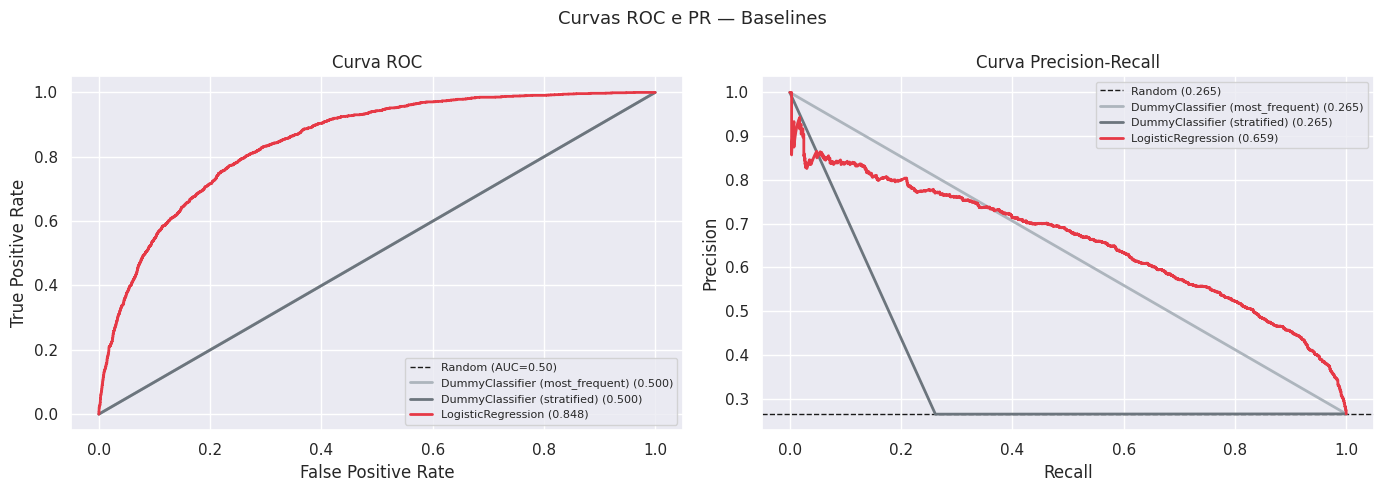

In [6]:
colors = ['#adb5bd', '#6c757d', '#e63946']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')
for (name, prob), color in zip(probas.items(), colors):
    fpr, tpr, _ = roc_curve(y, prob)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} ({auc(fpr, tpr):.3f})')
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='Curva ROC')
axes[0].legend(fontsize=8)

# PR
axes[1].axhline(y.mean(), color='k', linestyle='--', lw=1, label=f'Random ({y.mean():.3f})')
for (name, prob), color in zip(probas.items(), colors):
    prec, rec, _ = precision_recall_curve(y, prob)
    score = average_precision_score(y, prob)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} ({score:.3f})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Curva Precision-Recall')
axes[1].legend(fontsize=8)

plt.suptitle('Curvas ROC e PR — Baselines', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Análise de Threshold — LogisticRegression

```
Expected Profit = TP × 1140 - FP × 60 - FN × 1200
```

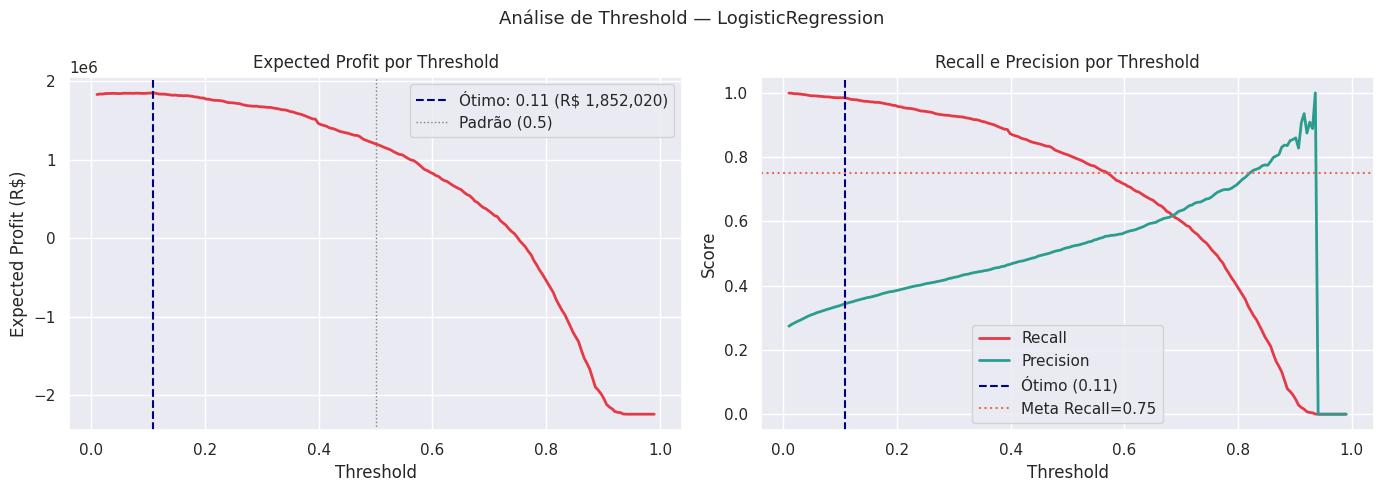

Threshold ótimo: 0.11 | Profit: R$ 1,852,020
Recall: 0.9845 | Precision: 0.3437


In [7]:
lr_prob = probas['LogisticRegression']
thresholds = np.linspace(0.01, 0.99, 200)
profits, recalls_t, precisions_t = [], [], []

for t in thresholds:
    y_pred_t = (lr_prob >= t).astype(int)
    TP = int(((y_pred_t == 1) & (y == 1)).sum())
    FP = int(((y_pred_t == 1) & (y == 0)).sum())
    FN = int(((y_pred_t == 0) & (y == 1)).sum())
    profits.append(TP * 1140 - FP * 60 - FN * 1200)
    recalls_t.append(recall_score(y, y_pred_t, zero_division=0))
    precisions_t.append(precision_score(y, y_pred_t, zero_division=0))

best_idx = np.argmax(profits)
best_thresh = thresholds[best_idx]
best_profit = profits[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, profits, color='#e63946', lw=2)
axes[0].axvline(best_thresh, color='navy', linestyle='--', lw=1.5,
                label=f'Ótimo: {best_thresh:.2f} (R$ {best_profit:,.0f})')
axes[0].axvline(0.5, color='gray', linestyle=':', lw=1, label='Padrão (0.5)')
axes[0].set(xlabel='Threshold', ylabel='Expected Profit (R$)', title='Expected Profit por Threshold')
axes[0].legend()

axes[1].plot(thresholds, recalls_t,    color='#e63946', lw=2, label='Recall')
axes[1].plot(thresholds, precisions_t, color='#2a9d8f', lw=2, label='Precision')
axes[1].axvline(best_thresh, color='navy', linestyle='--', lw=1.5, label=f'Ótimo ({best_thresh:.2f})')
axes[1].axhline(0.75, color='#e76f51', linestyle=':', lw=1.5, label='Meta Recall=0.75')
axes[1].set(xlabel='Threshold', ylabel='Score', title='Recall e Precision por Threshold')
axes[1].legend()

plt.suptitle('Análise de Threshold — LogisticRegression', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Threshold ótimo: {best_thresh:.2f} | Profit: R$ {best_profit:,.0f}')
print(f'Recall: {recalls_t[best_idx]:.4f} | Precision: {precisions_t[best_idx]:.4f}')

## 8. Matriz de Confusão — LogisticRegression

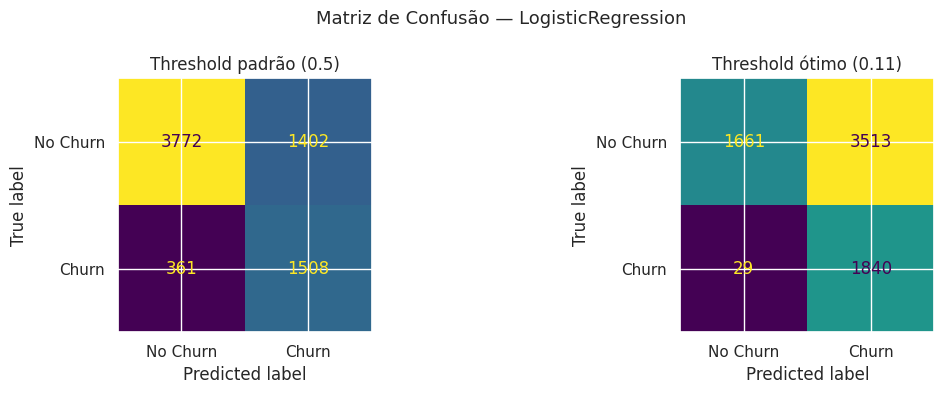

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, thresh, title in zip(
    axes,
    [0.5, best_thresh],
    ['Threshold padrão (0.5)', f'Threshold ótimo ({best_thresh:.2f})'],
):
    y_pred_t = (lr_prob >= thresh).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y, y_pred_t),
                           display_labels=['No Churn', 'Churn']).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle('Matriz de Confusão — LogisticRegression', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Conclusão — Meta para o MLP

In [9]:
lr = results_df.loc['LogisticRegression']

print('=' * 55)
print('CONCLUSÃO — BASELINES ETAPA 1')
print('=' * 55)
print(f'\nMelhor baseline: LogisticRegression (class_weight=balanced)')
print(f'  Recall:    {lr["recall"]:.4f}  ← meta ≥ 0.75  ✅')
print(f'  PR-AUC:    {lr["pr_auc"]:.4f}  ← métrica técnica principal')
print(f'  AUC-ROC:   {lr["roc_auc"]:.4f}')
print(f'  F1:        {lr["f1"]:.4f}')
print(f'  Precision: {lr["precision"]:.4f}')
print(f'\nThreshold ótimo: {best_thresh:.2f} → Profit R$ {best_profit:,.0f}')
print(f'\nMeta para o MLP (Etapa 2) — superar em todas as 4 métricas:')
print(f'  Recall  ≥ 0.75              (restrição de negócio)')
print(f'  PR-AUC  > {lr["pr_auc"]:.4f}  (métrica técnica principal)')
print(f'  AUC-ROC > {lr["roc_auc"]:.4f}')
print(f'  F1      > {lr["f1"]:.4f}')
print(f'\nRuns registrados no MLflow: experiment="churn-baselines"')

CONCLUSÃO — BASELINES ETAPA 1

Melhor baseline: LogisticRegression (class_weight=balanced)
  Recall:    0.8015  ← meta ≥ 0.75  ✅
  PR-AUC:    0.6554  ← métrica técnica principal
  AUC-ROC:   0.8449
  F1:        0.6256
  Precision: 0.5130

Threshold ótimo: 0.11 → Profit R$ 1,852,020

Meta para o MLP (Etapa 2) — superar em todas as 4 métricas:
  Recall  ≥ 0.75              (restrição de negócio)
  PR-AUC  > 0.6554  (métrica técnica principal)
  AUC-ROC > 0.8449
  F1      > 0.6256

Runs registrados no MLflow: experiment="churn-baselines"
